# Chapter 21: Systematic Debottlenecking and Utilization Analysis

This notebook demonstrates a systematic approach to **debottlenecking** a gas
processing facility. We build a 5-equipment process train, identify the bottleneck
at design rate, remove it by increasing capacity, and repeat — revealing the
**bottleneck cascade** that governs plant throughput.

In [1]:
# Execute against the selected, compiled NeqSim source checkout.
import os
import sys
from pathlib import Path
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import jpype

if not os.environ.get("NEQSIM_PROJECT_ROOT"):
    raise RuntimeError("Set NEQSIM_PROJECT_ROOT to the NeqSim source checkout before running.")
PROJECT_ROOT = Path(os.environ["NEQSIM_PROJECT_ROOT"]).resolve()
if not (PROJECT_ROOT / "devtools" / "neqsim_dev_setup.py").exists():
    raise RuntimeError("NEQSIM_PROJECT_ROOT must contain devtools/neqsim_dev_setup.py.")
sys.path.insert(0, str(PROJECT_ROOT / "devtools"))
from neqsim_dev_setup import neqsim_init, neqsim_classes
ns = neqsim_classes(neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=False))
jneqsim = jpype.JPackage("neqsim")
NEQSIM_MODE = "devtools"
NOTEBOOK_PATH = Path(globals().get("__vsc_ipynb_file__", Path.cwd() / "ch21_debottlenecking.ipynb")).resolve()
BOOK_ROOT = NOTEBOOK_PATH.parents[3]
FIGURES_DIR = NOTEBOOK_PATH.parent.parent / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
sys.path.insert(0, str(BOOK_ROOT / "devtools"))
from book_figure_tools import configure_figures, export_figure_summary
configure_figures()
print(f"NeqSim source: {PROJECT_ROOT}; Python: {sys.executable}")

# Named NeqSim class bindings used throughout the chapter.
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
SystemPrEos = jneqsim.thermo.system.SystemPrEos
SystemSrkCPAstatoil = jneqsim.thermo.system.SystemSrkCPAstatoil
ThermodynamicOperations = jneqsim.thermodynamicoperations.ThermodynamicOperations
Stream = jneqsim.process.equipment.stream.Stream
Separator = jneqsim.process.equipment.separator.Separator
ThreePhaseSeparator = jneqsim.process.equipment.separator.ThreePhaseSeparator
Compressor = jneqsim.process.equipment.compressor.Compressor
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
Heater = jneqsim.process.equipment.heatexchanger.Heater
HeatExchanger = jneqsim.process.equipment.heatexchanger.HeatExchanger
Mixer = jneqsim.process.equipment.mixer.Mixer
Splitter = jneqsim.process.equipment.splitter.Splitter
ThrottlingValve = jneqsim.process.equipment.valve.ThrottlingValve
Pump = jneqsim.process.equipment.pump.Pump
Expander = jneqsim.process.equipment.expander.Expander
Recycle = jneqsim.process.equipment.util.Recycle
ProcessSystem = jneqsim.process.processmodel.ProcessSystem


All NeqSim classes imported OK
NeqSim source: C:\Users\solbraa\OneDrive - NTNU\Documents\ChatGPT\NeqSim; Python: C:\Users\solbraa\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\python.exe


## 21.1 Define the Gas Processing Train

Our facility has five main equipment items in series:

1. **Inlet Separator** — designed for 60,000 kg/hr
2. **Gas Compressor (Stage 1)** — designed for 5,000 kW
3. **After Cooler** — designed for 8,000 kW duty
4. **Gas Compressor (Stage 2)** — designed for 4,500 kW
5. **Export Cooler** — designed for 6,000 kW duty

Each equipment has a **design capacity**. Utilization = actual load / design capacity.

In [2]:
# Equipment design capacities
equipment_names = ["Inlet Separator", "Compressor Stage 1", "After Cooler",
                   "Compressor Stage 2", "Export Cooler"]
capacity_units = ["kg/hr", "kW", "kW", "kW", "kW"]

# Initial design capacities — Stage 2 compressor is the tightest
design_capacities = np.array([60000.0, 5000.0, 8000.0, 4500.0, 6000.0])

# Actual loads at target throughput (55,000 kg/hr feed)
actual_loads = np.array([55000.0, 4200.0, 6800.0, 4400.0, 5200.0])

utilizations = actual_loads / design_capacities * 100.0

print(f"{'Equipment':<25} {'Capacity':>10} {'Load':>10} {'Util [%]':>10}")
print("-" * 60)
for name, cap, load, util, unit in zip(equipment_names, design_capacities, actual_loads, utilizations, capacity_units):
    flag = " *** BOTTLENECK" if util == max(utilizations) else ""
    print(f"{name:<25} {cap:>8.0f} {unit}  {load:>8.0f}  {util:>8.1f}%{flag}")

Equipment                   Capacity       Load   Util [%]
------------------------------------------------------------
Inlet Separator              60000 kg/hr     55000      91.7%
Compressor Stage 1            5000 kW      4200      84.0%
After Cooler                  8000 kW      6800      85.0%
Compressor Stage 2            4500 kW      4400      97.8% *** BOTTLENECK
Export Cooler                 6000 kW      5200      86.7%


## 21.2 Build and Run the NeqSim Process Model

We build the actual process in NeqSim to get realistic equipment loads.

In [3]:
fluid = jneqsim.thermo.system.SystemSrkEos(273.15 + 25.0, 35.0)
fluid.addComponent("methane", 0.85)
fluid.addComponent("ethane", 0.08)
fluid.addComponent("propane", 0.04)
fluid.addComponent("n-pentane", 0.02)
fluid.addComponent("water", 0.01)
fluid.setMixingRule("classic")
fluid.setMultiPhaseCheck(True)

feed = jneqsim.process.equipment.stream.Stream("Feed", fluid)
feed.setFlowRate(55000.0, "kg/hr")
feed.setTemperature(25.0, "C")
feed.setPressure(35.0, "bara")

sep = jneqsim.process.equipment.separator.Separator("Inlet Separator", feed)

comp1 = jneqsim.process.equipment.compressor.Compressor("Compressor Stage 1", sep.getGasOutStream())
comp1.setOutletPressure(70.0)

cooler1 = jneqsim.process.equipment.heatexchanger.Cooler("After Cooler", comp1.getOutletStream())
cooler1.setOutTemperature(273.15 + 30.0)

comp2 = jneqsim.process.equipment.compressor.Compressor("Compressor Stage 2", cooler1.getOutletStream())
comp2.setOutletPressure(150.0)

cooler2 = jneqsim.process.equipment.heatexchanger.Cooler("Export Cooler", comp2.getOutletStream())
cooler2.setOutTemperature(273.15 + 35.0)

process = jneqsim.process.processmodel.ProcessSystem()
process.add(feed)
process.add(sep)
process.add(comp1)
process.add(cooler1)
process.add(comp2)
process.add(cooler2)
process.run()

print(f"Compressor Stage 1 power: {comp1.getPower('kW'):.0f} kW")
print(f"Compressor Stage 2 power: {comp2.getPower('kW'):.0f} kW")
print(f"Export temperature: {cooler2.getOutletStream().getTemperature('C'):.1f} C")

Compressor Stage 1 power: 1315 kW
Compressor Stage 2 power: 1403 kW
Export temperature: 35.0 C


## 21.3 Iterative Debottlenecking

We systematically remove bottlenecks by increasing the design capacity of the
tightest equipment by 30%, then re-evaluate utilizations. This reveals the
**bottleneck cascade** — removing one bottleneck exposes the next.

In [4]:
# Debottlenecking simulation
capacities_history = [design_capacities.copy()]
util_history = [utilizations.copy()]
bottleneck_history = [equipment_names[np.argmax(utilizations)]]

current_capacities = design_capacities.copy()
current_loads = actual_loads.copy()

for step in range(3):
    # Find current bottleneck
    utils = current_loads / current_capacities * 100.0
    bottleneck_idx = np.argmax(utils)

    print(f"\n--- Debottleneck Step {step+1} ---")
    print(f"Bottleneck: {equipment_names[bottleneck_idx]} at {utils[bottleneck_idx]:.1f}% utilization")

    # Increase bottleneck capacity by 30%
    current_capacities[bottleneck_idx] *= 1.30
    print(f"Increased {equipment_names[bottleneck_idx]} capacity by 30%")

    # With higher throughput possible, increase all loads by 5%
    current_loads *= 1.05

    new_utils = current_loads / current_capacities * 100.0
    capacities_history.append(current_capacities.copy())
    util_history.append(new_utils.copy())
    bottleneck_history.append(equipment_names[np.argmax(new_utils)])

    print(f"New bottleneck: {equipment_names[np.argmax(new_utils)]} at {max(new_utils):.1f}%")

print(f"\nBottleneck cascade: {' -> '.join(bottleneck_history)}")


--- Debottleneck Step 1 ---
Bottleneck: Compressor Stage 2 at 97.8% utilization
Increased Compressor Stage 2 capacity by 30%
New bottleneck: Inlet Separator at 96.2%

--- Debottleneck Step 2 ---
Bottleneck: Inlet Separator at 96.2% utilization
Increased Inlet Separator capacity by 30%
New bottleneck: Export Cooler at 95.5%

--- Debottleneck Step 3 ---
Bottleneck: Export Cooler at 95.5% utilization
Increased Export Cooler capacity by 30%
New bottleneck: After Cooler at 98.4%

Bottleneck cascade: Compressor Stage 2 -> Inlet Separator -> Export Cooler -> After Cooler


Figure saved to ../figures/ch21_debottleneck_cascade.png


ch21_debottlenecking.ipynb:cell8:26: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


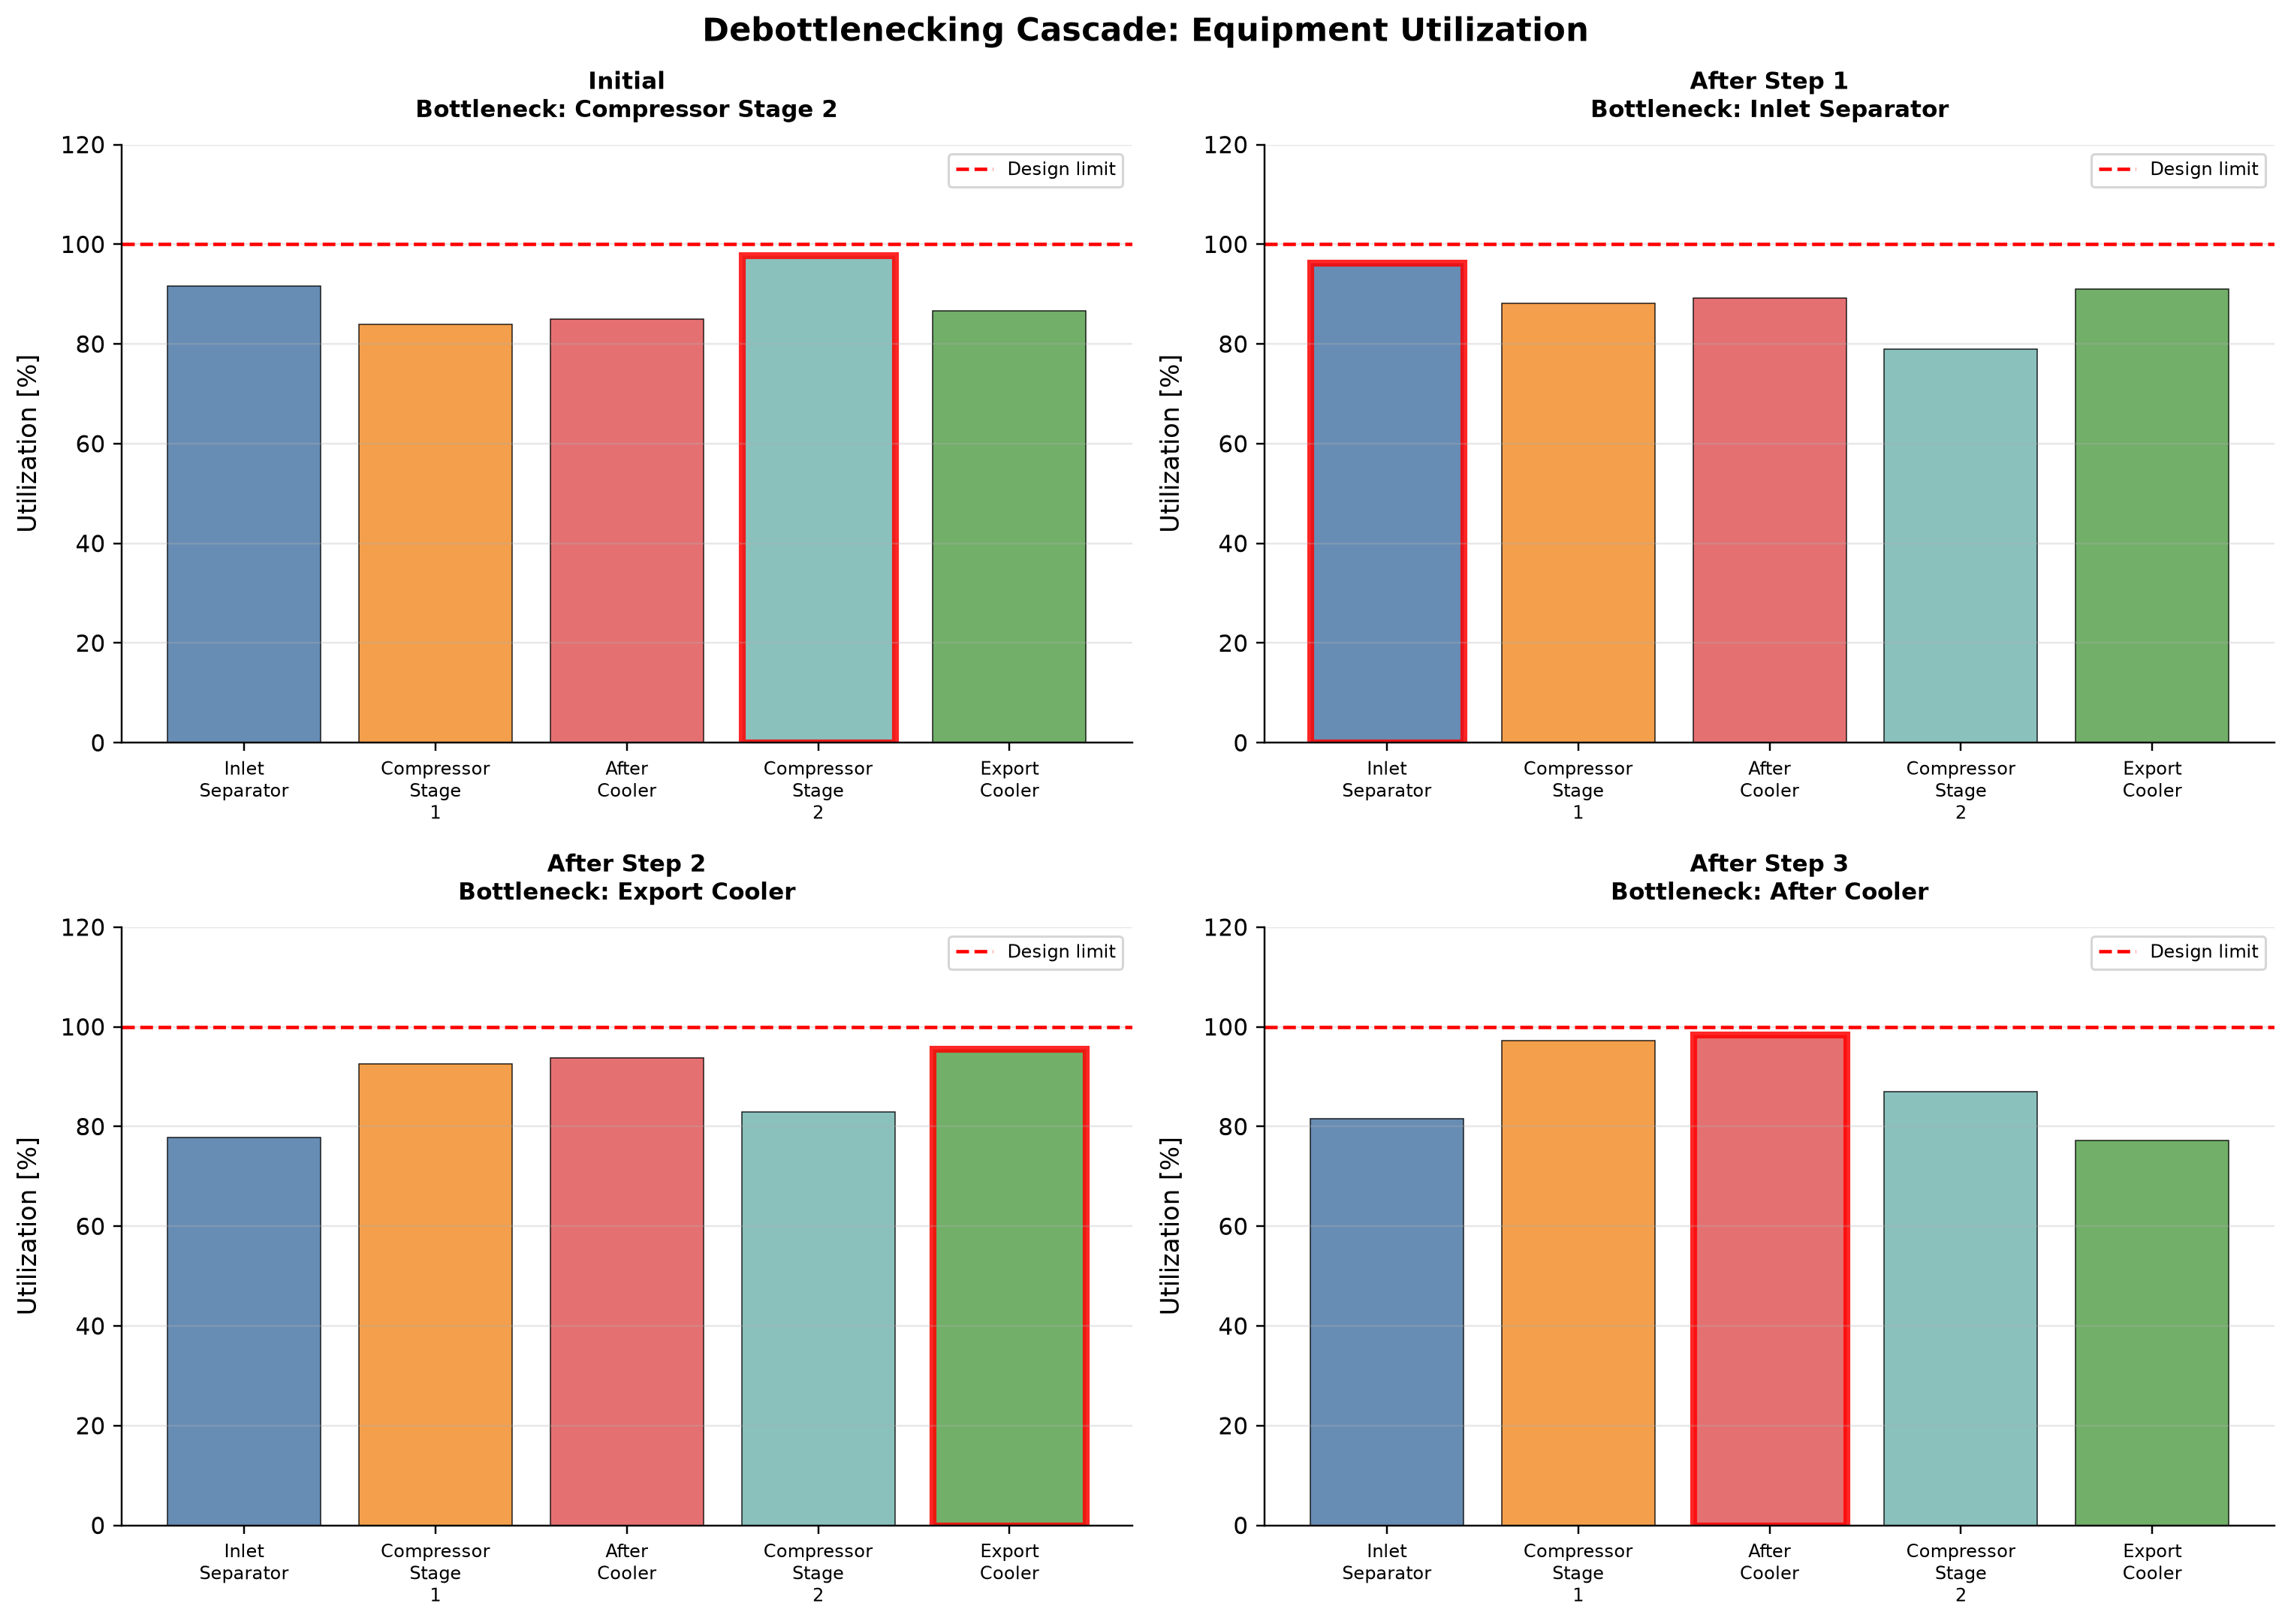

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
step_labels = ["Initial", "After Step 1", "After Step 2", "After Step 3"]
colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f']

for idx, (ax, utils, label, bn) in enumerate(zip(axes, util_history, step_labels, bottleneck_history)):
    bars = ax.bar(range(len(equipment_names)), utils, color=colors, alpha=0.85, edgecolor='black', linewidth=0.5)

    # Highlight bottleneck
    bn_idx = np.argmax(utils)
    bars[bn_idx].set_edgecolor('red')
    bars[bn_idx].set_linewidth(3)

    ax.axhline(y=100, color='red', linestyle='--', linewidth=1.5, label='Design limit')
    ax.set_xticks(range(len(equipment_names)))
    ax.set_xticklabels([n.replace(' ', '\n') for n in equipment_names], fontsize=8)
    ax.set_ylabel('Utilization [%]')
    ax.set_title(f"{label}\nBottleneck: {bn}", fontsize=10)
    ax.set_ylim(0, 120)
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(fontsize=8)

plt.suptitle('Debottlenecking Cascade: Equipment Utilization', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ch21_debottleneck_cascade.png', dpi=220, bbox_inches="tight")
plt.show()
print("Figure saved to ../figures/ch21_debottleneck_cascade.png")

**Executed-figure discussion.** Utilization spans 84–97.78 % across the plotted cases. Utilization spans 78.97–96.25 % across the plotted cases.

This arithmetic cascade increases a selected equipment rating, then scales assumed loads until the next unit becomes limiting. The diagram explains bottleneck migration; it is not a flowsheet simulation of an equipment retrofit. Use the cascade to prioritize full-process reruns, with pressure, phase split and power recalculated after each change.


## 21.4 Summary

**Key takeaways:**

1. **Utilization analysis** (actual load / design capacity) identifies the active bottleneck.
2. Removing one bottleneck **reveals the next** — the bottleneck cascade.
3. Systematic debottlenecking should evaluate **cost per incremental barrel** at each step.
4. Equipment close to 100% utilization are candidates for monitoring and early intervention.
5. NeqSim process models enable rapid what-if analysis for debottlenecking studies.

## Numerical output and figure provenance
The following table is extracted from the plotted numerical data. Each saved figure has an adjacent CSV and JSON record; missing points remain visible and are not replaced by interpolated results. Extrema summarize the sampled operating envelope, and are not independent validation of the model.


In [6]:
figure_results = export_figure_summary(NOTEBOOK_PATH)
print(figure_results.to_string(index=False, float_format=lambda value: f'{value:.6g}'))


                       Figure  Panel       Series   Output / unit  Minimum  Maximum  Finite points  Missing points
ch21_debottleneck_cascade.png      1 Design limit Utilization [%]      100      100              2               0
ch21_debottleneck_cascade.png      1       Bars 1 Utilization [%]       84  97.7778              5               0
ch21_debottleneck_cascade.png      2 Design limit Utilization [%]      100      100              2               0
ch21_debottleneck_cascade.png      2       Bars 1 Utilization [%]  78.9744    96.25              5               0
ch21_debottleneck_cascade.png      3 Design limit Utilization [%]      100      100              2               0
ch21_debottleneck_cascade.png      3       Bars 1 Utilization [%]  77.7404    95.55              5               0
ch21_debottleneck_cascade.png      4 Design limit Utilization [%]      100      100              2               0
ch21_debottleneck_cascade.png      4       Bars 1 Utilization [%]   77.175  98.3